In [1]:
import os
import random
import pickle
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report

import cv2
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications.inception_v3 import preprocess_input, InceptionV3

2026-02-02 14:15:45.823849: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770041746.004527      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770041746.056632      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770041746.488087      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770041746.488140      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770041746.488143      55 computation_placer.cc:177] computation placer alr

In [2]:
train_dir = Path("/kaggle/input/pharaohs-300-augmented/augmented_train_300")
valid_dir = Path("/kaggle/input/pharaohs-300-augmented/validation_dataset_300")
test_dir = Path("/kaggle/input/pharaohs-300-augmented/test_dataset_300")

In [3]:
AUTOTUNE = tf.data.AUTOTUNE
IMG_SIZE = 299
BATCH_SIZE = 32

In [4]:
IMG_EXTS = {".jpg"}  

def list_subdirs(path: Path):
    return sorted([p for p in path.iterdir() if p.is_dir()])

def make_df(root: Path):
    rows = []
    for class_dir in list_subdirs(root):
        label = class_dir.name
        for p in class_dir.iterdir():
            if p.is_file() and p.suffix.lower() in IMG_EXTS:
                rows.append({"label": label, "path": str(p)})
    return pd.DataFrame(rows, columns=["label", "path"])

def count_per_class(root: Path, classes):
    out = {}
    for c in classes:
        out[c] = sum(1 for p in (root / c).iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS)
    return out

In [5]:
train_df = make_df(train_dir)
val_df   = make_df(valid_dir)
test_df  = make_df(test_dir)

print("Train df:", train_df.shape)
print("Val df  :", val_df.shape)
print("Test df :", test_df.shape)

Train df: (20210, 2)
Val df  : (1395, 2)
Test df : (599, 2)


In [6]:
# classes from train 
classes = sorted(train_df["label"].unique().tolist())
print("Number of classes:", len(classes))
print("Sample classes:", classes[:10])

# sanity: same class set in val/test
print("Val classes match train:",  set(val_df["label"].unique()) == set(classes))
print("Test classes match train:", set(test_df["label"].unique()) == set(classes))

Number of classes: 96
Sample classes: ['Achoris', 'Ahmose_I', 'Akhenaton', 'Alexander_the_Great', 'Amasis_II', 'Amenemhat_I', 'Amenemhat_III', 'Amenhotep_II', 'Amenhotep_III', 'Amenhotep_III_and_God_Re-Horakhty']
Val classes match train: True
Test classes match train: True


In [7]:
train_counts = count_per_class(train_dir, classes)
val_counts   = count_per_class(valid_dir, classes)

train_vals = np.array([train_counts[c] for c in classes])
val_vals   = np.array([val_counts[c] for c in classes])

In [8]:
print("Train min/max:", train_vals.min(), train_vals.max(),
      "ratio:", train_vals.max() / max(1, train_vals.min()))
print("Val   min/max:", val_vals.min(), val_vals.max())

Train min/max: 144 300 ratio: 2.0833333333333335
Val   min/max: 4 42


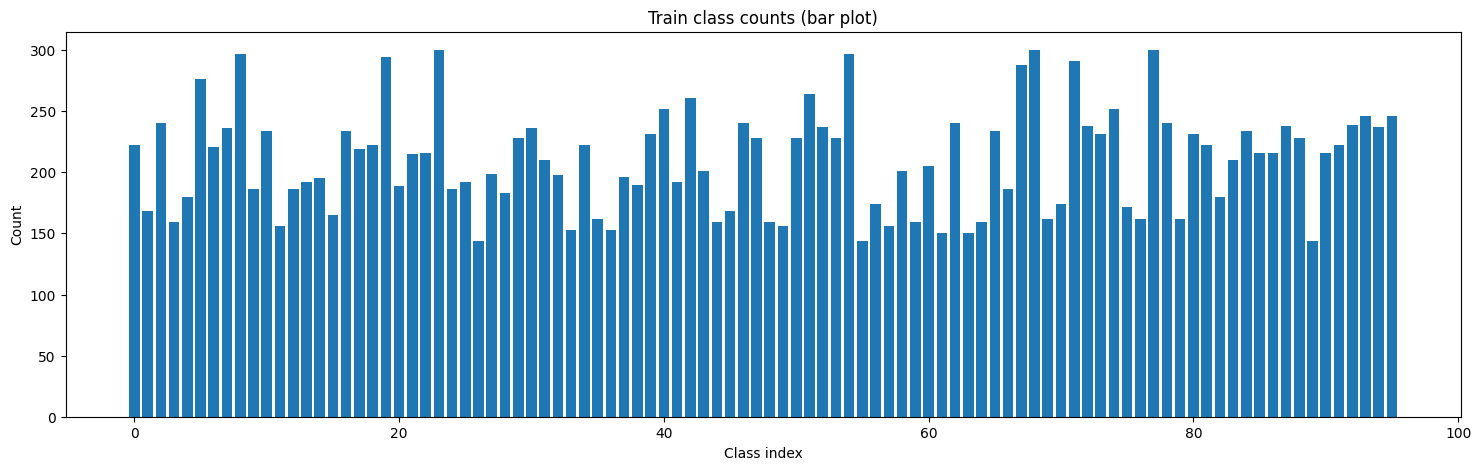

In [9]:
plt.figure(figsize=(18, 5))
plt.bar(range(len(classes)), train_vals)
plt.title("Train class counts (bar plot)")
plt.xlabel("Class index")
plt.ylabel("Count")
plt.show()

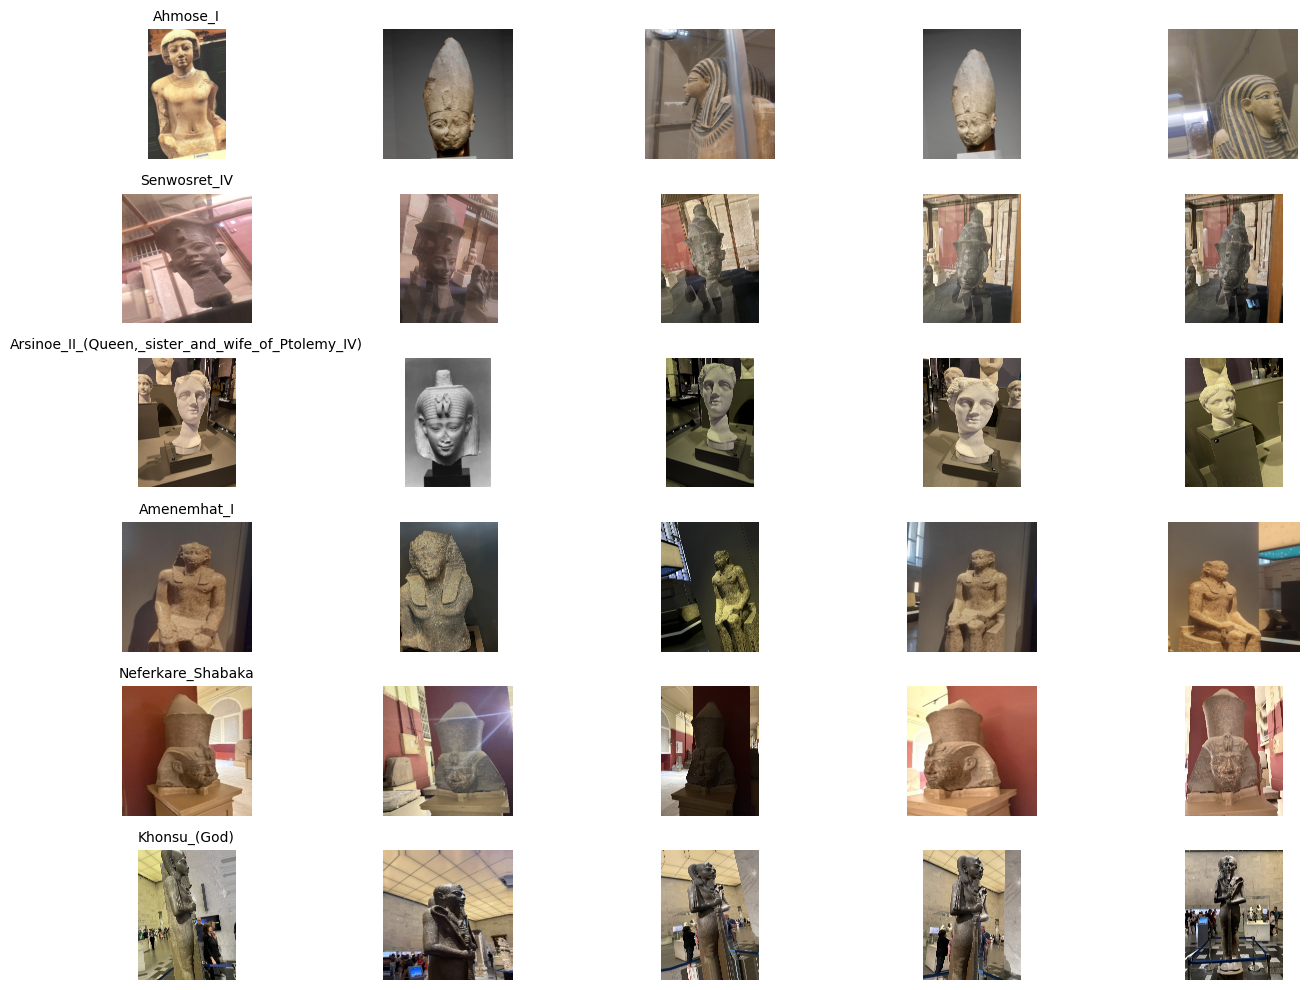

In [10]:
def show_samples_per_class(root: Path, class_names, k=5, rows=6):
    plt.figure(figsize=(14, 10))
    shown = 0
    picked = random.sample(class_names, min(len(class_names), rows))

    for cls in picked:
        imgs = [p for p in (root/cls).iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS]
        if not imgs:
            continue
        for i in range(min(k, len(imgs))):
            img_path = str(random.choice(imgs))
            img = tf.keras.utils.load_img(img_path)
            ax = plt.subplot(rows, k, shown + 1)
            plt.imshow(img)
            plt.axis("off")
            if i == 0:
                ax.set_title(cls, fontsize=10)
            shown += 1
            if shown >= rows * k:
                break
        if shown >= rows * k:
            break

    plt.tight_layout()
    plt.show()

show_samples_per_class(train_dir, classes, k=5, rows=6)

In [11]:
encoder = LabelEncoder()

train_df["label_enc"] = encoder.fit_transform(train_df["label"])
val_df["label_enc"]   = encoder.transform(val_df["label"])
test_df["label_enc"]  = encoder.transform(test_df["label"])

NUM_CLASSES = len(encoder.classes_)
print("NUM_CLASSES:", NUM_CLASSES)

NUM_CLASSES: 96


In [12]:
y_train = train_df["label_enc"].values
classes_int = np.unique(y_train)

cw = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=classes_int,
    y=y_train)
cw

array([0.94829204, 1.2531002 , 0.87717014, 1.3240304 , 1.16956019,
       0.76275664, 0.95258296, 0.89203743, 0.70882435, 1.13183244,
       0.89966168, 1.34949252, 1.13183244, 1.09646267, 1.07959402,
       1.27588384, 0.89966168, 0.96128234, 0.94829204, 0.71605726,
       1.11386684, 0.97916667, 0.97463349, 0.70173611, 1.13183244,
       1.09646267, 1.46195023, 1.05789363, 1.15038707, 0.92333699,
       0.89203743, 1.00248016, 1.06323653, 1.37595316, 0.94829204,
       1.29951132, 1.37595316, 1.07408588, 1.10800439, 0.9113456 ,
       0.83540013, 1.09646267, 0.80659323, 1.04736733, 1.3240304 ,
       1.2531002 , 0.87717014, 0.92333699, 1.3240304 , 1.34949252,
       0.92333699, 0.7974274 , 0.88827356, 0.92333699, 0.70882435,
       1.46195023, 1.20988985, 1.34949252, 1.04736733, 1.3240304 ,
       1.02693089, 1.40347222, 0.87717014, 1.40347222, 1.3240304 ,
       0.89966168, 1.13183244, 0.73097512, 0.70173611, 1.29951132,
       1.20988985, 0.72343929, 0.88454132, 0.9113456 , 0.83540

In [13]:
cw_dict = {int(c): float(w) for c, w in zip(classes_int, cw)}
cw_dict

{0: 0.9482920420420421,
 1: 1.2531001984126984,
 2: 0.8771701388888888,
 3: 1.3240303983228512,
 4: 1.1695601851851851,
 5: 0.7627566425120773,
 6: 0.9525829562594268,
 7: 0.892037429378531,
 8: 0.708824354657688,
 9: 1.1318324372759856,
 10: 0.8996616809116809,
 11: 1.3494925213675213,
 12: 1.1318324372759856,
 13: 1.0964626736111112,
 14: 1.079594017094017,
 15: 1.2758838383838385,
 16: 0.8996616809116809,
 17: 0.9612823439878234,
 18: 0.9482920420420421,
 19: 0.7160572562358276,
 20: 1.1138668430335097,
 21: 0.9791666666666666,
 22: 0.974633487654321,
 23: 0.7017361111111111,
 24: 1.1318324372759856,
 25: 1.0964626736111112,
 26: 1.4619502314814814,
 27: 1.057893634840871,
 28: 1.150387067395264,
 29: 0.9233369883040936,
 30: 0.892037429378531,
 31: 1.0024801587301588,
 32: 1.063236531986532,
 33: 1.3759531590413943,
 34: 0.9482920420420421,
 35: 1.299511316872428,
 36: 1.3759531590413943,
 37: 1.0740858843537415,
 38: 1.1080043859649122,
 39: 0.9113455988455988,
 40: 0.835400132275

In [14]:
cw_vec = np.zeros(NUM_CLASSES, dtype=np.float32)
for c, w in cw_dict.items():
    cw_vec[int(c)] = float(w)

cw_tf = tf.constant(cw_vec, dtype=tf.float32)
print("Example weights:", list(cw_dict.items())[:10])

Example weights: [(0, 0.9482920420420421), (1, 1.2531001984126984), (2, 0.8771701388888888), (3, 1.3240303983228512), (4, 1.1695601851851851), (5, 0.7627566425120773), (6, 0.9525829562594268), (7, 0.892037429378531), (8, 0.708824354657688), (9, 1.1318324372759856)]


I0000 00:00:1770041854.481864      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [15]:
def preprocess_image_tf(path, size=IMG_SIZE):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32) * 255.0
    img = tf.image.resize(img, (size, size), method="area")
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img

In [16]:
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05,fill_mode="reflect"),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.06, 0.06, fill_mode="reflect"),
], name="data_aug")

In [17]:
class TFDataset:
    def __init__(self, df, batch_size=BATCH_SIZE, shuffle=True, image_size=IMG_SIZE, augment=False):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.image_size = image_size if isinstance(image_size, int) else image_size[0]
        self.dataset = self._build_dataset()

    def _load_and_preprocess(self, path, label):
        img = preprocess_image_tf(path, size=self.image_size)
        label = tf.cast(label, tf.int32)
        return img, label

    def _maybe_augment(self, img, label):
        if self.augment:
            img = data_aug(img, training=True)
        return img, label

    def _build_dataset(self):
        paths = self.df["path"].values
        labels = self.df["label_enc"].values.astype(np.int32)

        ds = tf.data.Dataset.from_tensor_slices((paths, labels))

        if self.shuffle:
            ds = ds.shuffle(buffer_size=len(self.df), reshuffle_each_iteration=True)

        ds = ds.map(self._load_and_preprocess, num_parallel_calls=AUTOTUNE)
        ds = ds.map(self._maybe_augment, num_parallel_calls=AUTOTUNE)
        ds = ds.batch(self.batch_size).prefetch(AUTOTUNE)
        return ds

    def __iter__(self):
        return iter(self.dataset)

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))


In [18]:
train_ds = TFDataset(train_df, augment=True, shuffle=True).dataset
val_ds   = TFDataset(val_df,   augment=False, shuffle=False).dataset
test_ds  = TFDataset(test_df,  augment=False, shuffle=False).dataset

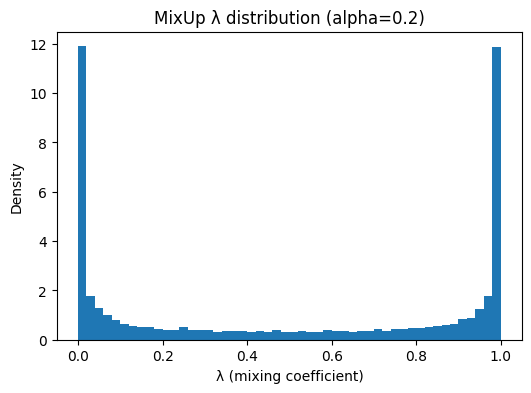

In [19]:
#  λ distribution
# plot to justify MixUp hyperparameter choice (α).
alpha = 0.2
N = 10000

lam = np.random.beta(alpha, alpha, N)

plt.figure(figsize=(6,4))
plt.hist(lam, bins=50, density=True)
plt.xlabel("λ (mixing coefficient)")
plt.ylabel("Density")
plt.title(f"MixUp λ distribution (alpha={alpha})")
plt.show()

In [20]:
MIXUP_ALPHA = 0.2
MIXUP_PROB  = 0.4

def _sample_beta(alpha, shape):
    g1 = tf.random.gamma(shape, alpha)
    g2 = tf.random.gamma(shape, alpha)
    return g1 / (g1 + g2)

def _to_onehot(labels_int):
    return tf.one_hot(labels_int, NUM_CLASSES, dtype=tf.float32)

def _sample_weight_from_onehot(y_onehot):
    # expected weight per sample: sum_j y_j * w_j
    return tf.reduce_sum(y_onehot * cw_tf[None, :], axis=1)  # (B,)


In [21]:
def mixup_batch(images, labels_int):
    B = tf.shape(images)[0]
    y1 = _to_onehot(labels_int)

    idx = tf.random.shuffle(tf.range(B))
    x2 = tf.gather(images, idx)
    y2 = tf.gather(y1, idx)

    lam = _sample_beta(MIXUP_ALPHA, [B])
    lam_x = tf.reshape(lam, [B, 1, 1, 1])
    lam_y = tf.reshape(lam, [B, 1])

    x = images * lam_x + x2 * (1.0 - lam_x)
    y = y1 * lam_y + y2 * (1.0 - lam_y)

    sw = _sample_weight_from_onehot(y)
    return x, y, sw

def plain_batch_train(images, labels_int):
    y = _to_onehot(labels_int)
    sw = _sample_weight_from_onehot(y)
    return images, y, sw

def maybe_mixup(images, labels_int):
    do = tf.random.uniform([]) < MIXUP_PROB
    return tf.cond(
        do,
        lambda: mixup_batch(images, labels_int),
        lambda: plain_batch_train(images, labels_int),
    )

def plain_batch_eval(images, labels_int):
    y = _to_onehot(labels_int)
    return images, y

In [22]:
# Train: MixUp + weights
train_ds = (
    train_ds
    .map(maybe_mixup, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

# Val/Test: no MixUp, but convert to onehot 
val_ds = (
    val_ds
    .map(plain_batch_eval, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(plain_batch_eval, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

In [23]:
base = InceptionV3(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [24]:
def build_model(base,img_size=IMG_SIZE, dropout=0.3):
    inputs = layers.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, kernel_regularizer=tf.keras.regularizers.l2(1e-4), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(1e-4), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(dropout*0.7)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)
    model = Model(inputs, outputs)
    
    return model

In [25]:
model = build_model(base, IMG_SIZE, dropout=0.25)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,048,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_94 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_95          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_95 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 96)             │        24,672 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,010,176 (87.78 MB)

 Trainable params: 22,974,208 (87.64 MB)

 Non-trainable params: 35,968 (140.50 KB)

In [27]:
base.trainable = True
unfreeze_from = int(len(base.layers) * 0.5)

for layer in base.layers[:unfreeze_from]:
    layer.trainable = False

for layer in base.layers[unfreeze_from:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

In [28]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=3e-5, weight_decay=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["categorical_accuracy"]
)

In [29]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_inceptionv3_finetune.keras",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

In [30]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/30


I0000 00:00:1770042017.755988     121 service.cc:152] XLA service 0x7cc628001f10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770042017.756051     121 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1770042023.355806     121 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/632 ━━━━━━━━━━━━━━━━━━━━ 6:57:38 40s/step - categorical_accuracy: 0.0000e+00 - loss: 5.3266

I0000 00:00:1770042042.372676     121 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.0442 - loss: 4.7235
Epoch 1: val_loss improved from inf to 3.93854, saving model to best_inceptionv3_finetune.keras
632/632 ━━━━━━━━━━━━━━━━━━━━ 1413s 2s/step - categorical_accuracy: 0.0443 - loss: 4.7230 - val_categorical_accuracy: 0.1713 - val_loss: 3.9385 - learning_rate: 3.0000e-05
Epoch 2/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.2154 - loss: 3.7893
Epoch 2: val_loss improved from 3.93854 to 3.36782, saving model to best_inceptionv3_finetune.keras
632/632 ━━━━━━━━━━━━━━━━━━━━ 1329s 2s/step - categorical_accuracy: 0.2155 - loss: 3.7891 - val_categorical_accuracy: 0.2659 - val_loss: 3.3678 - learning_rate: 3.0000e-05
Epoch 3/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.3371 - loss: 3.2896
Epoch 3: val_loss improved from 3.36782 to 2.87425, saving model to best_inceptionv3_finetune.keras
632/632 ━━━━━━━━━━━━━━━━━━━━ 1328s 2s/step - categorical_accuracy: 0.3371 - loss: 

In [38]:
model.save("/kaggle/working/inceptionv3_pharaohs300_aug_ft30.keras")

In [ ]:
def plot_history(h, title):
    plt.figure()
    plt.plot(h.history["categorical_accuracy"], label="train acc")
    plt.plot(h.history["val_categorical_accuracy"], label="val acc")
    plt.title(title)
    plt.legend()
    plt.show()


plot_history(history2, "Stage 2 (fine-tuning)")
print(history2.history.keys())

In [ ]:
final_train_loss = history.history["loss"][-1]
final_val_loss   = history.history["val_loss"][-1]

final_train_acc = history.history["categorical_accuracy"][-1]
final_val_acc   = history.history["val_categorical_accuracy"][-1]
print("Final Train accuracy: ", final_train_acc * 100)
print("Final Train loss: ", final_train_loss)
print("Final Validation accuracy: ", final_val_acc * 100)
print("Final Validation loss: ", final_val_loss)


In [ ]:
y_true, y_pred = [], []

for xb, yb in val_ds:
    preds = model.predict(xb, verbose=0)           # (B, num_classes)
    y_pred.extend(np.argmax(preds, axis=1).tolist())

    yb_np = yb.numpy()

    # If y is one-hot (B, C) -> convert to class id (B,)
    if yb_np.ndim > 1 and yb_np.shape[-1] > 1:
        yb_np = np.argmax(yb_np, axis=1)

    y_true.extend(yb_np.astype(int).tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(classes)))
print("Val accuracy:", (y_true == y_pred).mean())

print("\nClassification report (per-class):")
print(classification_report(y_true, y_pred,labels=np.arange(len(classes)),target_names=classes,digits=4))


In [ ]:
support = cm.sum(axis=1)          # number of true samples per class
cm_norm = cm / support[:, None]  # row-normalized confusion rates
confusions = []

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i != j and cm[i, j] > 0:
            confusions.append((
                cm[i, j],           # count
                cm_norm[i, j],      # rate
                classes[i],         # true
                classes[j]          # predicted
            ))


confusions.sort(reverse=True)       #sorted by count

print("Top confusions:")
for count, rate, true, pred in confusions[:15]:
    print(f"{true} -> {pred} : {count} ({rate*100:.2f}%)")


In [ ]:
support = cm.sum(axis=1)
cm_norm = cm / support[:, None]

print("All confusions (non-zero):")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i != j and cm[i, j] > 0:
            print(
                f"{classes[i]} → {classes[j]} : "
                f"{cm[i,j]}/{support[i]} "
                f"({cm_norm[i,j]*100:.2f}%)"
            )

In [35]:
# predictions
y_prob = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

# true labels (currently one-hot)
y_true_oh = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_true = np.argmax(y_true_oh, axis=1)

# accuracy
test_acc = (y_true == y_pred).mean()
print(f"Test accuracy: {test_acc:.4f}")

# report
print(classification_report(y_true, y_pred, target_names=encoder.classes_))

cm_test = confusion_matrix(y_true, y_pred)
print("Confusion matrix shape:", cm_test.shape)
print("\nConfusion Matrix:\n", cm_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step
Test accuracy: 0.8715
                                                                   precision    recall  f1-score   support

                                                          Achoris       1.00      1.00      1.00         6
                                                         Ahmose_I       1.00      1.00      1.00         2
                                                        Akhenaton       0.94      0.83      0.88        18
                                              Alexander_the_Great       1.00      1.00      1.00         4
                                                        Amasis_II       0.67      1.00      0.80         2
                                                      Amenemhat_I       0.67      1.00      0.80         4
                                                    Amenemhat_III       0.83      0.94      0.88        16
                                                     Amenhotep_II       0.84      

In [36]:
print(f"Test accuracy: {test_acc*100:.4f}")

Test accuracy: 87.1452


In [ ]:
support_test = cm_test.sum(axis=1)
cm_norm_test = cm_test / support_test[:, None]

print("All confusions (non-zero):")
for i in range(cm_test.shape[0]):
    for j in range(cm_test.shape[1]):
        if i != j and cm_test[i, j] > 0:
            print(
                f"{classes[i]} → {classes[j]} : "
                f"{cm_test[i,j]}/{support_test[i]} "
                f"({cm_norm_test[i,j]*100:.2f}%)"
            )


In [ ]:
#sorted by rate
support_test = cm_test.sum(axis=1)
cm_norm_test = cm_test / support_test[:, None]
all_confusions_test =[]

print("All confusions (non-zero):")
for i in range(cm_test.shape[0]):
    for j in range(cm_test.shape[1]):
        if i != j and cm_test[i, j] > 0:
           all_confusions_test.append((cm_norm_test[i,j], cm_test[i,j], classes[i], classes[j]))

all_confusions_test.sort(reverse=True) # sorts by rate first

print("Top confusions by RATE:")
for rate, count, true, pred in all_confusions_test:
    print(f"{true} → {pred} :  {count}/{support_test[classes.index(true)]} ({rate*100:.2f}%)")

In [39]:
with open("/kaggle/working/encoder_inceptionv3_pharaohs300_aug.pkl", "wb") as f:
    pickle.dump(encoder, f)